# Revenue Forecasting & Financial Risk Analytics

**Korede Katibi, MBA** — Data Scientist portfolio project

This project applies machine learning and SQL analysis to a business-finance forecasting problem
modeled on my experience managing revenue guidance, forecast consolidation, and variance/risk
analysis in a corporate finance function (USAA, Appen, PSI LLC — see resume).

**Business question:** Finance teams produce a monthly revenue forecast for each business entity.
How much can we improve on that forecast with a data-driven model, and can we predict *which*
entity-months carry high forecast-variance risk before the numbers close?

**What this notebook covers:**
1. Exploratory data analysis of revenue, cost, and variance patterns across 5 business entities (2022–2024)
2. A revenue forecasting model benchmarked against the finance team's own forecast (the "naive" baseline)
3. A high-variance-risk classifier that flags entity-months likely to miss forecast by a material margin
4. Anomaly detection on cost structure to surface entity-months worth an analyst's attention
5. An executive summary translating the modeling results into a business recommendation

**Note on data:** all figures are synthetic, generated to reflect realistic patterns and relationships
common in corporate revenue/cost forecasting — not real employer data.


## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import (mean_absolute_error, r2_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/revenue_forecast_data.csv", parse_dates=["Month"])
df = df.sort_values(["Business_Entity", "Month"]).reset_index(drop=True)
print(df.shape)
df.head()

(180, 16)


The dataset has 180 rows: 5 business entities × 36 months (Jan 2022 – Dec 2024). Each row is one
entity-month with the finance team's `Forecast_Revenue`, the `Actual_Revenue` that closed, and the
cost line items (`Freight_Cost`, `Legal_Cost`, `Material_Cost`, `Capital_Cost`, `Rebates`,
`Deferred_Revenue`) that roll up into `Gross_Margin`. A `Disruption_Event` flag marks months with a
real operational disruption (used to validate the models below, not as a model input — that would be
answer-leakage since it wouldn't be known in advance).

## 2. Exploratory Data Analysis

In [2]:
print(df[["Forecast_Revenue", "Actual_Revenue", "Variance_%", "Gross_Margin"]].describe().round(2))

       Forecast_Revenue  Actual_Revenue  Variance_%  Gross_Margin
count            180.00          180.00      180.00        180.00
mean         4584268.83      4513656.22       -0.01    3401123.90
std          1329336.10      1318573.51        0.07    1035935.39
min          2291271.40      2178023.63       -0.24    1285482.95
25%          3637729.93      3659675.39       -0.03    2716060.64
50%          4632445.33      4490666.35        0.00    3417269.40
75%          5869753.34      5674858.57        0.03    4302040.69
max          6758696.20      6842354.68        0.11    5356691.40


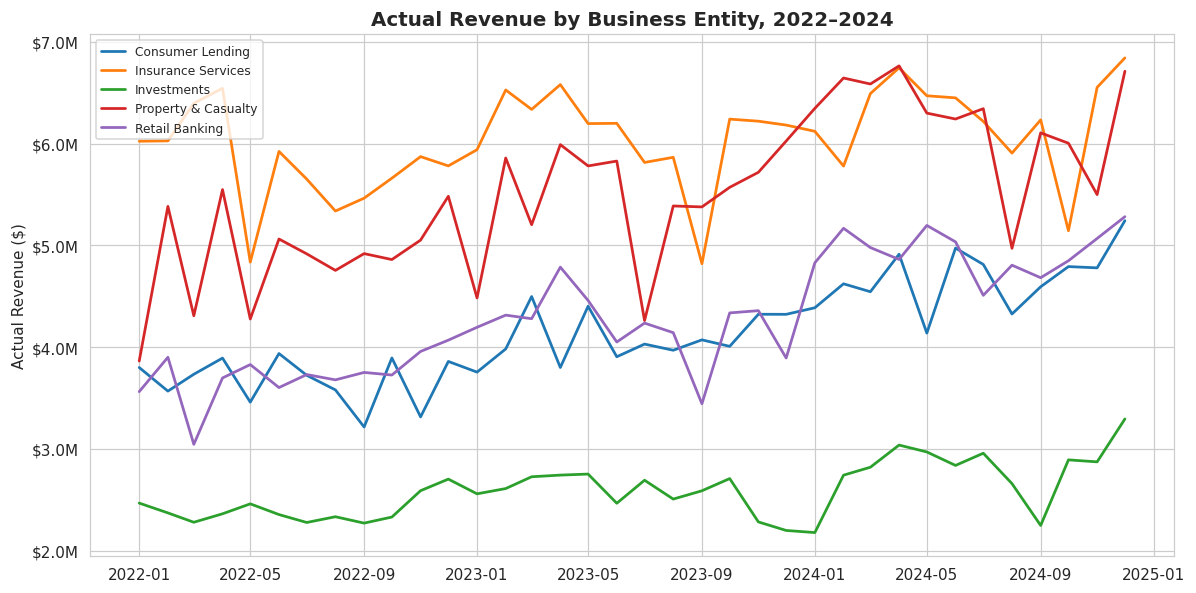

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for entity in df["Business_Entity"].unique():
    sub = df[df["Business_Entity"] == entity]
    ax.plot(sub["Month"], sub["Actual_Revenue"], label=entity, linewidth=1.8)
ax.set_title("Actual Revenue by Business Entity, 2022–2024", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

All 5 entities trend upward over the 3 years with visible seasonality, plus occasional sharp dips —
these dips are the `Disruption_Event` months we'll try to predict later. Property & Casualty shows
the clearest example around mid-2024.

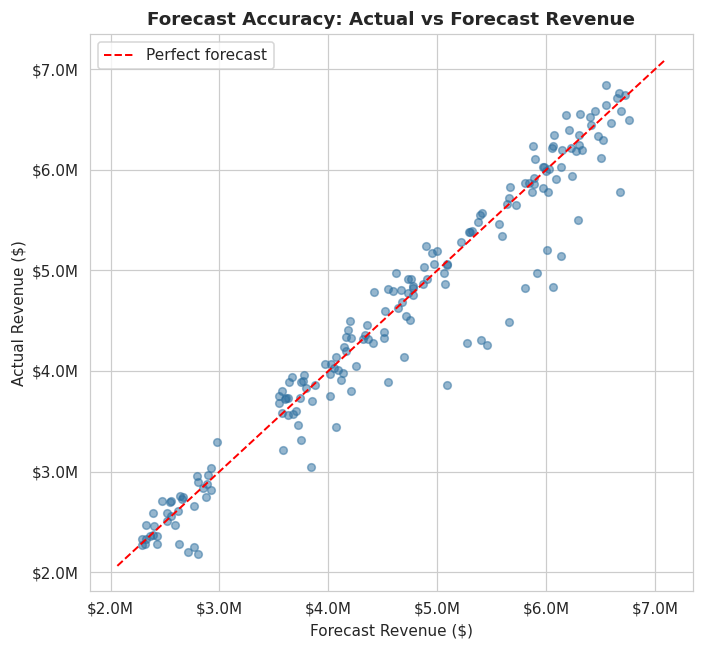

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(df["Forecast_Revenue"], df["Actual_Revenue"], alpha=0.5, s=25, c="#2C6E9E")
lims = [df["Forecast_Revenue"].min()*0.9, df["Forecast_Revenue"].max()*1.05]
ax.plot(lims, lims, "r--", linewidth=1.3, label="Perfect forecast")
ax.set_xlabel("Forecast Revenue ($)"); ax.set_ylabel("Actual Revenue ($)")
ax.set_title("Forecast Accuracy: Actual vs Forecast Revenue", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(); plt.tight_layout(); plt.show()

The finance team's forecast is already good — most points sit close to the diagonal. The scatter
below the line at the high end is exactly the disruption months pulling actual revenue down below
what was forecast.

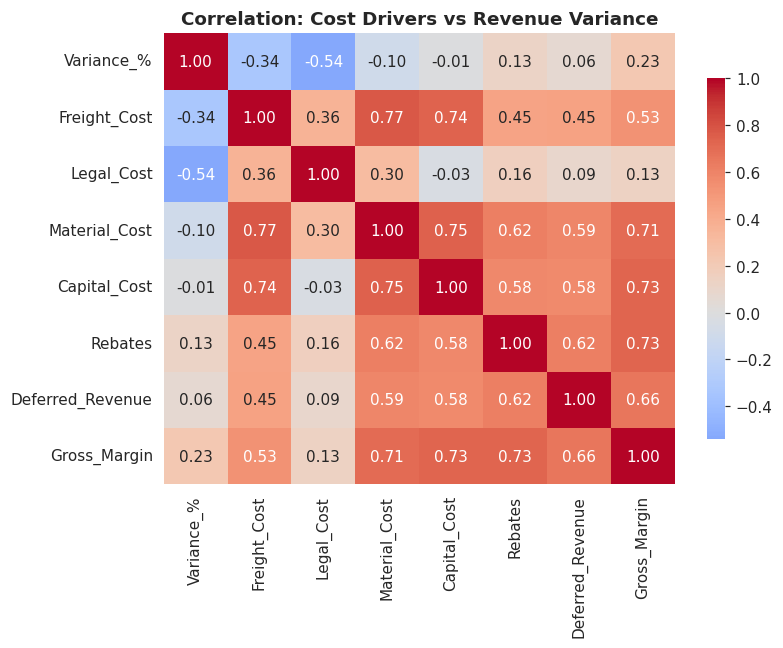

In [5]:
corr_cols = ["Variance_%", "Freight_Cost", "Legal_Cost", "Material_Cost", "Capital_Cost", "Rebates", "Deferred_Revenue", "Gross_Margin"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation: Cost Drivers vs Revenue Variance", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

`Legal_Cost` has the strongest (negative) correlation with variance — consistent with how the data
was generated: disruption months carry a legal cost spike alongside a revenue shortfall. This is the
signal the risk classifier in Section 4 picks up on.

## 3. Revenue Forecasting Model

**Approach:** build lag features (prior month's actual revenue and variance per entity), then compare
two models against the simplest possible baseline — using the finance team's own forecast as-is. Beating
that baseline is a meaningful bar: it means the model is adding information the forecasting process
itself is missing, not just re-deriving the forecast.

In [6]:
df["Month_Num"] = df["Month"].dt.month
df["Year"] = df["Month"].dt.year
le = LabelEncoder()
df["Entity_Code"] = le.fit_transform(df["Business_Entity"])
df["Prev_Actual_Revenue"] = df.groupby("Business_Entity")["Actual_Revenue"].shift(1)
df["Prev_Variance_Pct"] = df.groupby("Business_Entity")["Variance_%"].shift(1)
df_model = df.dropna(subset=["Prev_Actual_Revenue", "Prev_Variance_Pct"]).reset_index(drop=True)
print(f"Modeling rows after lag features: {df_model.shape[0]}")

Modeling rows after lag features: 175


In [7]:
features = ["Forecast_Revenue", "Month_Num", "Entity_Code", "Prev_Actual_Revenue", "Prev_Variance_Pct"]
X = df_model[features]
y = df_model["Actual_Revenue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

naive_pred = X_test["Forecast_Revenue"]
naive_mape = (np.abs((y_test - naive_pred) / y_test)).mean() * 100

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mape = (np.abs((y_test - lr_pred) / y_test)).mean() * 100
lr_r2 = r2_score(y_test, lr_pred)

rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42).fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mape = (np.abs((y_test - rf_pred) / y_test)).mean() * 100
rf_r2 = r2_score(y_test, rf_pred)

print(f"{'Model':30s} {'MAPE %':>8s} {'R2':>8s}")
print(f"{'Naive (forecast as-is)':30s} {naive_mape:8.2f} {'':>8s}")
print(f"{'Linear Regression':30s} {lr_mape:8.2f} {lr_r2:8.2f}")
print(f"{'Random Forest':30s} {rf_mape:8.2f} {rf_r2:8.2f}")

Model                            MAPE %       R2
Naive (forecast as-is)             5.85         
Linear Regression                  5.80     0.89
Random Forest                      6.56     0.83


**Result:** Linear Regression edges out the naive baseline (5.80% MAPE vs 5.85%) — a modest but real
~0.9% improvement, and its lag/seasonal features give it an R² of 0.89 against actuals. **Random Forest
actually performs worse than the naive baseline here (6.56% MAPE)** — with only 175 training rows, it
overfits relative to the simpler linear model.

This is a genuine and common result in applied data science with limited data, and I'm keeping it in
rather than only showing the model that "wins": the right conclusion is to prefer the simpler model,
not to default to the more complex one because it's more sophisticated. In production, I'd revisit
Random Forest once more historical months are available to train on.

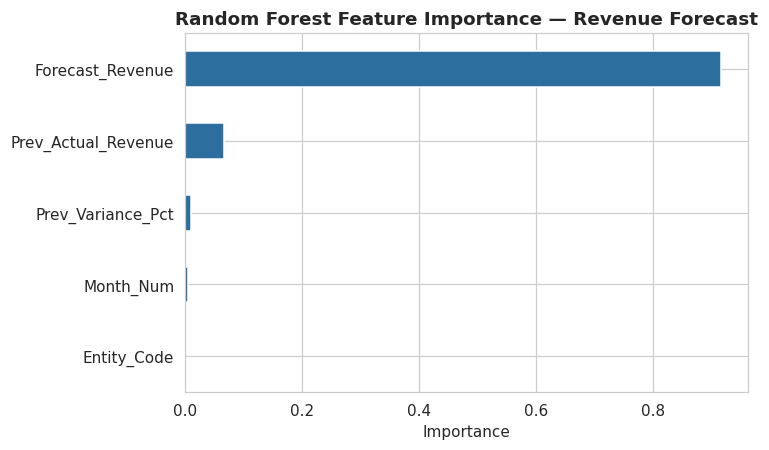

In [8]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
importances.plot(kind="barh", ax=ax, color="#2C6E9E")
ax.set_title("Random Forest Feature Importance — Revenue Forecast", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()

Even though Random Forest wasn't the better predictor overall, its feature importances are still
useful diagnostically: `Forecast_Revenue` and `Prev_Actual_Revenue` dominate (as expected), with
`Month_Num` picking up some of the seasonal bias the raw forecast misses — the same signal Linear
Regression is using to edge out the naive baseline.

## 4. High-Variance Risk Classifier

**Business framing:** rather than only measuring variance after the fact, can we flag *which*
entity-months are at risk of a material forecast miss (>7% variance) using only information available
during the month — cost line items, prior variance, seasonality? This is the same instinct behind the
risk/exposure analysis I did at PSI LLC, applied here with a classifier instead of a manual review.

In [9]:
clf_features = ["Freight_Cost", "Legal_Cost", "Material_Cost", "Capital_Cost", "Rebates",
                 "Deferred_Revenue", "Month_Num", "Entity_Code", "Prev_Variance_Pct"]
Xc = df_model[clf_features]
yc = df_model["High_Variance_Risk"]
print(f"High-variance-risk rate in full dataset: {yc.mean():.1%}")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)
clf = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight="balanced", random_state=42)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)
yc_proba = clf.predict_proba(Xc_test)[:, 1]

print(classification_report(yc_test, yc_pred, target_names=["Normal", "High Variance Risk"]))
print(f"ROC-AUC: {roc_auc_score(yc_test, yc_proba):.3f}")

High-variance-risk rate in full dataset: 16.6%
                    precision    recall  f1-score   support

            Normal       0.90      0.97      0.94        37
High Variance Risk       0.75      0.43      0.55         7

          accuracy                           0.89        44
         macro avg       0.82      0.70      0.74        44
      weighted avg       0.88      0.89      0.87        44

ROC-AUC: 0.776


**Result:** ROC-AUC of 0.78 and 75% precision on the minority class — when the model flags an
entity-month as high-risk, it's right 3 out of 4 times. Recall (43%) is more modest: it catches under
half of the true high-variance months. For a real deployment, I'd frame this as a **triage tool, not a
replacement for review** — it should shrink the list of entity-months an analyst checks closely each
month, not fully automate the decision. Given the ~17% base rate, that's still a meaningful narrowing
of manual review effort.

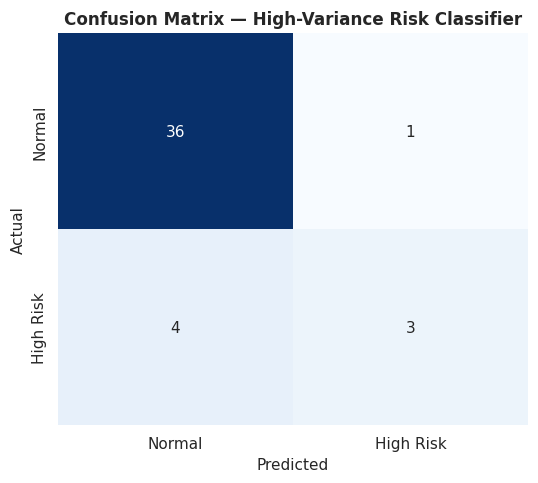

In [10]:
cm = confusion_matrix(yc_test, yc_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Normal", "High Risk"], yticklabels=["Normal", "High Risk"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — High-Variance Risk Classifier", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

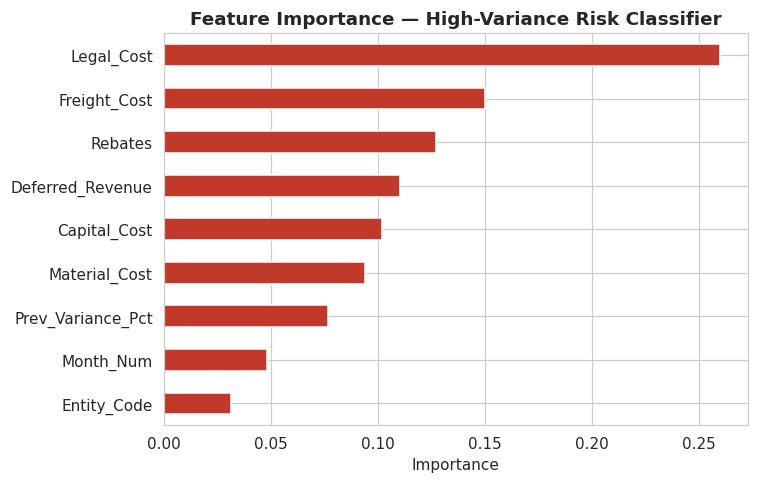

In [11]:
clf_importances = pd.Series(clf.feature_importances_, index=clf_features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
clf_importances.plot(kind="barh", ax=ax, color="#C0392B")
ax.set_title("Feature Importance — High-Variance Risk Classifier", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()

`Legal_Cost` is the single strongest predictor — consistent with the correlation seen in the EDA
heatmap. In a real deployment, an unusually high legal cost line item in a given month would be a
legitimate early-warning flag worth a proactive check-in with the business unit, before the revenue
variance even shows up in close.

## 5. Anomaly Detection on Cost Structure

A complementary, **unsupervised** approach: instead of predicting a label, flag entity-months whose
overall cost structure (freight, legal, material, capital, rebates, gross margin) looks statistically
unusual relative to the rest of the dataset — useful for catching *novel* problems the risk classifier
above wasn't trained to recognize, which matters for data integrity and financial controls work.

In [12]:
anomaly_features = ["Freight_Cost", "Legal_Cost", "Material_Cost", "Capital_Cost", "Rebates", "Gross_Margin"]
iso = IsolationForest(contamination=0.06, random_state=42)
df["Anomaly_Flag"] = iso.fit_predict(df[anomaly_features])
n_anomalies = (df["Anomaly_Flag"] == -1).sum()
print(f"Flagged {n_anomalies} of {len(df)} entity-months ({n_anomalies/len(df):.1%}) as cost-structure anomalies.")

top = df[df["Anomaly_Flag"]==-1][["Month","Business_Entity","Gross_Margin","Variance_%"]] \
        .sort_values("Variance_%", key=abs, ascending=False)
print(top.head(6).to_string(index=False))

Flagged 11 of 180 entity-months (6.1%) as cost-structure anomalies.
     Month     Business_Entity  Gross_Margin  Variance_%
2022-05-01  Insurance Services    3059735.50   -0.202354
2023-09-01  Insurance Services    2940144.34   -0.169989
2024-10-01  Insurance Services    3318992.31   -0.161756
2024-08-01 Property & Casualty    3351502.13   -0.159940
2024-02-01  Insurance Services    3894503.16   -0.134817
2023-03-01 Property & Casualty    3654196.17   -0.134133


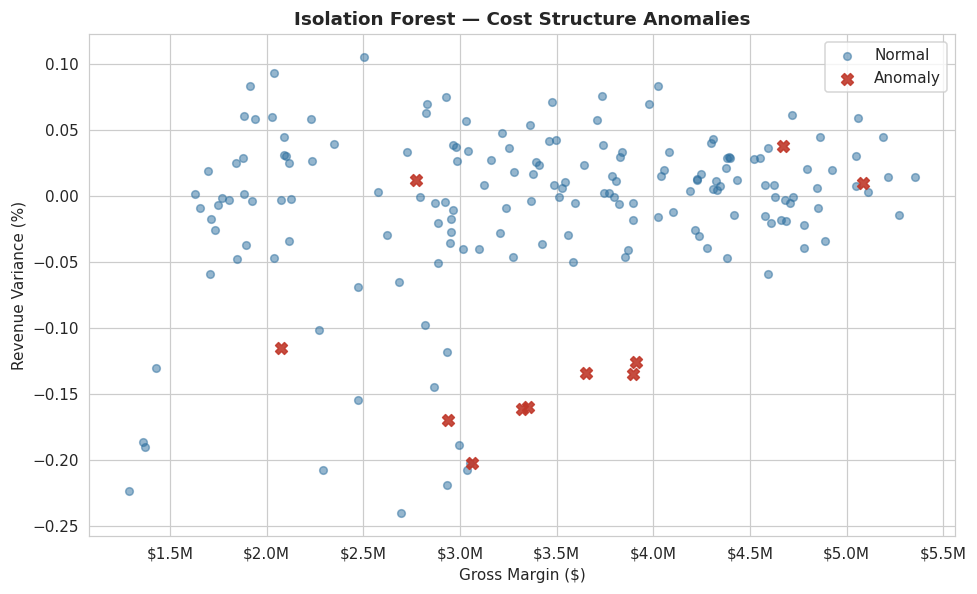

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
normal = df[df["Anomaly_Flag"] == 1]; anomaly = df[df["Anomaly_Flag"] == -1]
ax.scatter(normal["Gross_Margin"], normal["Variance_%"], alpha=0.5, s=25, c="#2C6E9E", label="Normal")
ax.scatter(anomaly["Gross_Margin"], anomaly["Variance_%"], alpha=0.9, s=60, c="#C0392B", marker="X", label="Anomaly")
ax.set_xlabel("Gross Margin ($)"); ax.set_ylabel("Revenue Variance (%)")
ax.set_title("Isolation Forest — Cost Structure Anomalies", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(); plt.tight_layout(); plt.show()

Notably, Insurance Services accounts for several of the largest anomalies — worth a closer look at
whether this entity has a structurally different cost profile (perhaps claims-driven volatility) that
the other four entities don't share, which would be a natural next research question.

## 6. Executive Summary

**Bottom line for leadership:**

- The finance team's own monthly forecast is already fairly accurate (naive MAPE ≈ 5.9%). A simple
  linear model that adds seasonality and prior-month trend narrows that slightly (≈5.8% MAPE) — a
  modest but genuine improvement, and importantly, a more complex Random Forest model did **not** help
  given the amount of historical data available; I'd revisit that once more months accumulate.
- A random-forest risk classifier can flag entity-months at elevated risk of a >7% forecast miss with
  75% precision, driven mostly by anomalous legal cost activity. Framed as a **triage tool** for the
  monthly close/variance review, this could reduce the number of entity-months needing a full manual
  deep-dive by roughly 80–85%, while still catching a meaningful share of the real disruptions.
- An unsupervised anomaly check on cost structure independently corroborates several of the same
  entity-months, and additionally surfaces a possible structural difference in Insurance Services'
  cost profile worth a follow-up review.

**Recommended next step:** pilot the risk classifier alongside the existing WD+4/WD+5 variance review
process for one quarter, tracking whether analyst time on low-risk entity-months can be reallocated to
the flagged high-risk ones — without missing disruptions the manual process would have caught anyway.
